In [1]:
#sqlite3 is a python library
import sqlite3
#It allows pytho to create, connect with the SQL database and to perform the SQL operations
import pandas as pd
#to work with the csv file as in the form of tables

import matplotlib.pyplot as plt
#to perform data visualization operation

import warnings
warnings.filterwarnings('ignore')
#supress non-crictical warning messages that cluttter output

print('All libraries imported successfully')

#to check for the versions
print(f'pandas version : {pd.__version__}')
print(f'sqlite3 version : {sqlite3.version}')

All libraries imported successfully
pandas version : 2.2.2
sqlite3 version : 2.6.0


In [2]:
#connecting or mounting the colab notebook to the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#loading the dataset
df=pd.read_csv('student_performance.csv')

In [4]:
#number of rows and columns in the csv file
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")

Dataset loaded: 30 students, 13 columns


In [5]:
#to print the columns in the vertical manner
df.columns.tolist()

['student_id',
 'name',
 'age',
 'gender',
 'department',
 'semester',
 'math_score',
 'science_score',
 'english_score',
 'programming_score',
 'attendance_percentage',
 'city',
 'admission_year']

In [6]:
#to print the columns name in the horizontal manner
print(f"Columns: {df.columns.tolist()}")

Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [7]:
#Step A: connect (or create) to a database file
conn=sqlite3.connect('college.db')
#'conn' = our connetion to the dataset
#'college.db' = the file that will be created in the Colab's filesystem
#If 'college.db' already exists , it just opens it
#if it doesn't exist, SQLite creates it automatically


In [8]:
#it is like a pen where we can write or do operation by sql commands in the database
cursor=conn.cursor()

In [9]:
#step c: write the dataframe to the database as a table
df.to_sql(
   'students',            #Name of the table to create in the databse
    conn,                  #Which database connection to use
    if_exists='replace',    #If 'students' table exists, replace it
    index=False            #Do Not write dataframe row number as column
)

30

In [10]:
#Step D:verify the table was created
cursor.execute("SELECT COUNT(*) FROM students")
#cursor.execute() runs a SQL command
#SELECT COUNT(*) count all rown in the students table

count= cursor.fetchone()[0]
#.fetchone() retrieves the first result row
#[0] gets the first value from that row (our count)
print(count)

30


In [11]:
#print using fetchall() function (NORMALLY)
cursor.execute('SELECT * FROM students')
result= cursor.fetchall()
print(result)

[(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023), (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023), (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023), (1004, 'Sneha Reddy', 20, 'Female', 'Mechanical', 2, 70, 80, 75, 48, 95, 'Hyderabad', 2023), (1005, 'Arjun Nair', 19, 'Male', 'Computer Science', 2, 92, 88, 81, 95, 90, 'Kochi', 2023), (1006, 'Meera Joshi', 20, 'Female', 'Electronics', 2, 58, 66, 70, 52, 72, 'Pune', 2023), (1007, 'Kiran Kumar', 21, 'Male', 'Civil', 2, 73, 69, 65, 40, 85, 'Bangalore', 2023), (1008, 'Divya Singh', 19, 'Female', 'Computer Science', 2, 88, 91, 84, 93, 96, 'Lucknow', 2023), (1009, 'Rahul Mishra', 20, 'Male', 'Mechanical', 2, 62, 71, 58, 45, 68, 'Varanasi', 2023), (1010, 'Ananya Das', 19, 'Female', 'Computer Science', 2, 95, 89, 90, 97, 98, 'Kolkata', 2023), (1011, 'Vikram Iyer', 20, 'Male', 'Electronics', 2, 80, 75, 68, 72, 83, '

In [12]:
#PRAGMA is a special SQlite command (not standard)
#table_info() shows the structure of the table
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
#.fetchall() retrieves all the result rows(not just one)
columns_info

[(0, 'student_id', 'INTEGER', 0, None, 0),
 (1, 'name', 'TEXT', 0, None, 0),
 (2, 'age', 'INTEGER', 0, None, 0),
 (3, 'gender', 'TEXT', 0, None, 0),
 (4, 'department', 'TEXT', 0, None, 0),
 (5, 'semester', 'INTEGER', 0, None, 0),
 (6, 'math_score', 'INTEGER', 0, None, 0),
 (7, 'science_score', 'INTEGER', 0, None, 0),
 (8, 'english_score', 'INTEGER', 0, None, 0),
 (9, 'programming_score', 'INTEGER', 0, None, 0),
 (10, 'attendance_percentage', 'INTEGER', 0, None, 0),
 (11, 'city', 'TEXT', 0, None, 0),
 (12, 'admission_year', 'INTEGER', 0, None, 0)]

In [13]:
#printing the students using PRAGMA
cursor.execute("PRAGMA table_info(students)")
result=cursor.execute("SELECT * FROM students")
result
columns_info=cursor.fetchall()
columns_info

[(1001,
  'Aarav Sharma',
  19,
  'Male',
  'Computer Science',
  2,
  85,
  78,
  72,
  91,
  92,
  'Mumbai',
  2023),
 (1002,
  'Priya Patel',
  20,
  'Female',
  'Computer Science',
  2,
  76,
  82,
  88,
  79,
  87,
  'Ahmedabad',
  2023),
 (1003,
  'Rohit Verma',
  19,
  'Male',
  'Electronics',
  2,
  65,
  74,
  61,
  55,
  78,
  'Delhi',
  2023),
 (1004,
  'Sneha Reddy',
  20,
  'Female',
  'Mechanical',
  2,
  70,
  80,
  75,
  48,
  95,
  'Hyderabad',
  2023),
 (1005,
  'Arjun Nair',
  19,
  'Male',
  'Computer Science',
  2,
  92,
  88,
  81,
  95,
  90,
  'Kochi',
  2023),
 (1006,
  'Meera Joshi',
  20,
  'Female',
  'Electronics',
  2,
  58,
  66,
  70,
  52,
  72,
  'Pune',
  2023),
 (1007,
  'Kiran Kumar',
  21,
  'Male',
  'Civil',
  2,
  73,
  69,
  65,
  40,
  85,
  'Bangalore',
  2023),
 (1008,
  'Divya Singh',
  19,
  'Female',
  'Computer Science',
  2,
  88,
  91,
  84,
  93,
  96,
  'Lucknow',
  2023),
 (1009,
  'Rahul Mishra',
  20,
  'Male',
  'Mechanical',
  2

In [14]:
#structured way to print the above data
print("Table structure of 'students")
print(f"{'Column Name':<25}{'Data types':<12}")
#.<25 means left-align in 25 characters (for neat formatting)
print("-"*38)
#for - 38 times
for col in columns_info:
  #col is a tuple:(id, name ,type)
  print(f"{col[1]:<25}{col[2]}")

Table structure of 'students
Column Name              Data types  
--------------------------------------
Aarav Sharma             19
Priya Patel              20
Rohit Verma              19
Sneha Reddy              20
Arjun Nair               19
Meera Joshi              20
Kiran Kumar              21
Divya Singh              19
Rahul Mishra             20
Ananya Das               19
Vikram Iyer              20
Pooja Gupta              19
Suresh Rao               21
Kavya Nambiar            20
Ajay Tiwari              19
Ritu Agarwal             20
Manoj Pandey             21
Swati Kulkarni           19
Deepak Chauhan           20
Nisha Kapoor             19
Harish Pillai            20
Tanvi Mehta              19
Sanjay Dubey             21
Preeti Saxena            20
Amit Bose                19
Rekha Nair               20
Gaurav Shukla            21
Sunita Pillai            19
Nitin Jain               20
Akanksha Yadav           19


# The Standard SQL Query Pattern
1. SELECT column1, column2 -- which col to show
2. FROM Table_name -- which table to read from
3. WHERE Condition -- Filters rows (Optional)
4. GROUPBY column -- Group rows(optional)
5. HAVING groupby_condition -- filters groups(Optional)
6. ORDER BY column DESC -- sort results (optional)
7. LIMIT 10 -- Max rows to return (optional)

In [15]:

#==========================================================
#CELL 5 :helper function to run SQL queries
#===========================================================

def run_query(sql,description=""):
  """Runs a SQL query and returns results as a pandas dataframe
  Parameters:
  ---------------------
  sql         : str  - the sql query string to execute
  description : str  - a label to print above the results

  Returns:
  --------
  pandas dataframe containing the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f"   {description}")
    print(f"{'='*55}")

  result=pd.read_sql_query(sql,conn)
  #pd.read_sql_query() does two things"
  #  1. Executes the SQL query against our database
  #  2. Converts the results into a pandas dataframe
  #this is the key function connecting SQL + Pandas


  print(result.to_string(index=False))
  #.tostring(index=False) prints the dataframe without row numbers

  return result
  #we return the dataframe so we can use it for charting later
print("Helper function 'run_query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully!
Usage: run_query(sql_string, description_label)


In [16]:
#=============================================================
#CELL 6:SQL Query 1 - Basic SELECT
#=============================================================
query1="""
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
LIMIT 10
"""
#SELECT   : keyword that starts every data retrieval query
#student_id, name, department, ... : columns we want to see
#FROM students  : which table to read from
#LIMIT 10 : return only the first 10 rows
#            Without LIMIT, ALL 30 ROWS would appear
#Triple quotes  """...""" let us write multi-line strings in python


result1 = run_query(query1,"First 10 students(SELECT + LIMIT)")




   First 10 students(SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [17]:
#=======================================================================================
#CELL 7 : Query 2 -ORDER BY + LIMIT
#=======================================================================================
query2="""
    SELECT name, department, math_score
    FROM students
    ORDER BY math_score DESC
    LIMIT 5
"""

#ORDER BY math_score  : sort by the math_score column
#DESC                 : descending order (highest first)
#                 ASC would be ascending (lowest first)
#LIMIT 5              :show only the top 5 results
#Pandas equivalent :df.sort_values('math_score',ascending=False).head(5)

result2 = run_query(query2,"Query 2 : Top 5 Math Scorers (ORDER BY DESC + LIMIT)")


   Query 2 : Top 5 Math Scorers (ORDER BY DESC + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [18]:

#========================================================================================================
#CELL 8: SQL Query - WHERE filter
#=======================================================================================================
query3="""
    SELECT name,math_score,science_score, programming_score,attendance_percentage
    FROM students
    WHERE department='Computer Science'
    ORDER BY programming_score DESC
    """

#WHERE department = 'Computer Science'
#  filters rows -  only return rows where department equals 'computer Scienc'
#  string values in SQL use SINGLE Quotes , not double quotes
#  SQL is case-sensitive for string values: 'computer science' would return 0 rows!
#
#pandas equivalent:df[df['department']=='computer science']

result3 = run_query(query3,"Computer Science Students (WHERE filter)")
print(f"\nTotal CS student found : {len(result3)}")m


   Computer Science Students (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79     

In [19]:

#========================================================================================================
#CELL 8: SQL Query - WHERE filter
#=======================================================================================================
query3="""
    SELECT name,math_score,science_score, programming_score,attendance_percentage
    FROM students
    WHERE department='Computer Science'
    ORDER BY programming_score DESC
    """

#WHERE department = 'Computer Science'
#  filters rows -  only return rows where department equals 'computer Scienc'
#  string values in SQL use SINGLE Quotes , not double quotes
#  SQL is case-sensitive for string values: 'computer science' would return 0 rows!
#
#pandas equivalent:df[df['department']=='computer science']

result3 = run_query(query3,"Computer Science Students (WHERE filter)")
print(f"\nTotal CS student found : {len(result3)}")


   Computer Science Students (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79     

In [20]:

query5 = """
    SELECT department,
    COUNT(*)                        AS  num_students,
    ROUND(AVG(math_score),2)        AS  avg_math,
    ROUND(AVG(science_score),2)     AS  avg_science,
    ROUND(AVG(programming_score),2) AS  avg_programming
    FROM students
    GROUP BY department
    ORDER BY num_students DESC
"""

#SELECT department   : the column we are grouping by
#COUNT(*)            : count of rows in each group
# AVG(math_score)    : average math score for each group
#ROUND(..., 2)       :round to 2 decimal places

result5=run_query(query5,"Query 5 : Department-wise Averages (GROUP BY + ORDER BY)")


   Query 5 : Department-wise Averages (GROUP BY + ORDER BY)
      department  num_students  avg_math  avg_science  avg_programming
Computer Science            13     85.62        84.46            89.23
      Mechanical             6     71.00        76.50            49.33
     Electronics             6     71.00        74.17            61.50
           Civil             5     63.40        66.60            40.60


In [21]:
query6 = """
    SELECT
        department,
        ROUND(AVG(math_score), 2)             AS avg_math,
        COUNT(*) AS students
    FROM students
    GROUP BY department
    HAVING AVG(math_score) > 70
    ORDER BY avg_math DESC
"""
result6 = run_query(query6, "Departments with more than 70 students (HAVING)")


   Departments with more than 70 students (HAVING)
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [22]:
query7="""
  SELECT
   gender,
   COUNT(*) AS num_students,
   ROUND(AVG(math_score), 2) AS avg_math,
   ROUND(AVG(programming_score), 2) AS avg_programming,
   ROUND(AVG(attendance_percentage), 2) AS avg_attendance
  FROM students
  GROUP BY gender
  """

result7=run_query(query7,"Query 7 :Gender wise Performance Analysis")


   Query 7 :Gender wise Performance Analysis
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [23]:
query8 = """
    SELECT
     name,
     department,
     math_score + science_score + english_score + programming_score AS total_score,
     attendance_percentage
    FROM students
    ORDER BY total_score DESC
    LIMIT 10
     """

result8=run_query(query8,"Query 8 : Top 10 Students by Total Score")


   Query 8 : Top 10 Students by Total Score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [24]:
import pandas as pd
#Creating the department table in the sql
dept_data ={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr. Sharma' , 'Dr. Reddy','Dr.Patel','Dr.Kumar'],
    'established': [1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created the department table: ")
print(dept_df.to_string(index=False))


Created the department table: 
dept_code        dept_name   hod_name  established  intake
       CS Computer Science Dr. Sharma         1985      60
       EC      Electronics  Dr. Reddy         1988      60
       ME       Mechanical   Dr.Patel         1972      60
       CE            Civil   Dr.Kumar         1965      60


In [25]:

dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)

print("Created 'departments' table:")
print(dept_df.to_string(index=False))

#now add dept_code to the students table so we can
#map department names to codes
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE',
}
#dictionary mapping full name -> code
df['dept_code']=df['department'].map(dept_map)
#.map() replaces each value using the dictionary
#'Computer Science' ->

# Re-save the students DataFrame to the database to include the new dept_code column
df.to_sql(
   'students',            #Name of the table to create in the databse
    conn,                  #Which database connection to use
    if_exists='replace',    #If 'students' table exists, replace it
    index=False            #Do Not write dataframe row number as column
)

Created 'departments' table:
dept_code        dept_name   hod_name  established  intake
       CS Computer Science Dr. Sharma         1985      60
       EC      Electronics  Dr. Reddy         1988      60
       ME       Mechanical   Dr.Patel         1972      60
       CE            Civil   Dr.Kumar         1965      60


30

In [26]:
query_join="""
    SELECT
      s.name,
      s.department,
      d.dept_name,
      d.hod_name,
      d.established
    FROM students AS s
    INNER JOIN departments AS d
      ON s.dept_code = d.dept_code
    ORDER BY s.math_score DESC
    LIMIT 8
"""

#FROM student AS s    :  'studnets' table, aliased as 's'
#INNER JOIN departments AS d :join with 'departments'table , aliased as 'd'
#ON s.dept_code =d.dept_code:
#    This is the JOIN CONDITION  -- the matching column in both tables
#    A row from students is combined with a row from departments
#    only when both tables have columns with the same name
#
#INNER JOIN returns only rows that have a MATCH
result_join=run_query(query_join,"JOIN: Students with the Department details " )


   JOIN: Students with the Department details 
          name       department        dept_name   hod_name  established
    Ananya Das Computer Science Computer Science Dr. Sharma         1985
   Tanvi Mehta Computer Science Computer Science Dr. Sharma         1985
    Arjun Nair Computer Science Computer Science Dr. Sharma         1985
Akanksha Yadav Computer Science Computer Science Dr. Sharma         1985
Swati Kulkarni Computer Science Computer Science Dr. Sharma         1985
   Divya Singh Computer Science Computer Science Dr. Sharma         1985
  Ritu Agarwal      Electronics      Electronics  Dr. Reddy         1988
     Amit Bose Computer Science Computer Science Dr. Sharma         1985


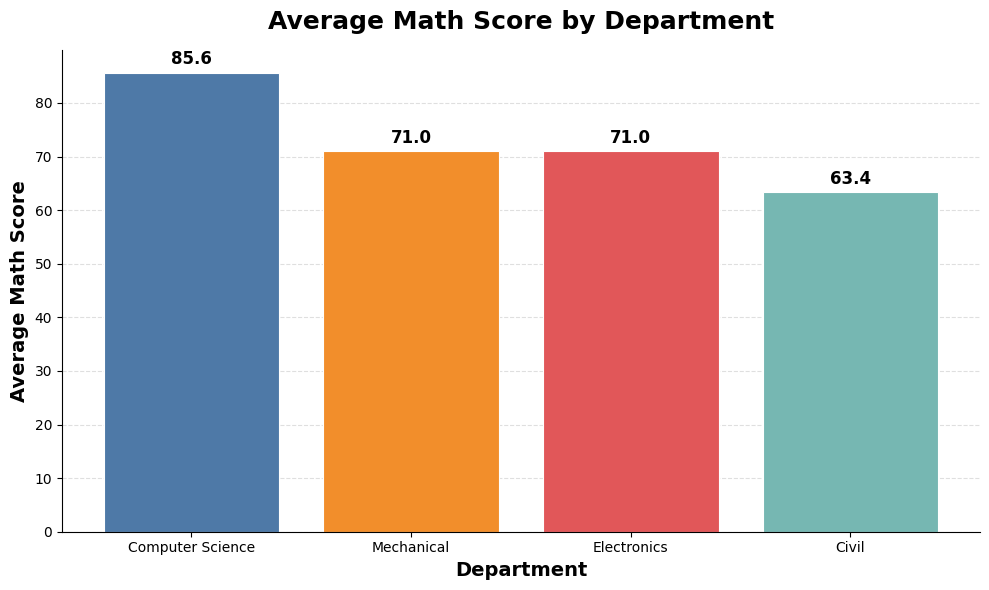

In [27]:
# ============================================================
# CELL 16: Chart 1 – Bar Chart: Average Math Score by Department
# ============================================================

# Step 1: Get data using SQL
chart1_sql = """
    SELECT department, ROUND(AVG(math_score), 2) AS avg_math
    FROM students
    GROUP BY department
    ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

# pd.read_sql_query runs the SQL and returns a DataFrame
# chart1_data has two columns: 'department' and 'avg_math'


# ============================================================
# Step 2: Define color palette
# ============================================================

# Same color palette as our PPT slides for consistency
bar_colors = [
    '#4E79A7',   # blue
    '#F28E2B',   # orange
    '#E15759',   # red
    '#76B7B2',   # teal
    '#59A14F',   # green
    '#EDC948',   # yellow
    '#B07AA1',   # purple
    '#FF9DA7'    # pink
]


# ============================================================
# Step 3: Create the bar chart
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# fig = the whole figure (canvas)
# ax  = the axes object (the actual plot area)
# figsize=(10, 6) = 10 inches wide, 6 inches tall


# ============================================================
# Step 4: Draw bars
# ============================================================

bars = ax.bar(
    chart1_data['department'],      # x-axis values (category labels)
    chart1_data['avg_math'],        # y-axis values (heights of bars)
    color=bar_colors,               # colors for each bar
    edgecolor='white',              # white border around each bar
    linewidth=0.8                   # thickness of the border
)

# ax.bar() draws one bar per x-value, with height = y-value


# ============================================================
# Step 5: Add value labels on top of bars
# ============================================================

for bar in bars:

    # Loop through each bar object
    height = bar.get_height()

    # .get_height() returns the bar's height (= avg_math value)

    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position: center of bar
        height + 0.8,                        # y position: just above bar top
        f'{height:.1f}',                     # text: height formatted to 1 decimal
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=12,
        fontweight='bold',
        color='black'
    )


# ============================================================
# Step 6: Add titles and labels
# ============================================================

ax.set_title(
    'Average Math Score by Department',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Department',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Average Math Score',
    fontsize=14,
    fontweight='bold'
)

# ============================================================
# Step 7: Customize grid and style
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

ax.set_axisbelow(True)

# Removes top and right borders for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# Step 8: Display chart
# ============================================================

plt.tight_layout()
plt.show()

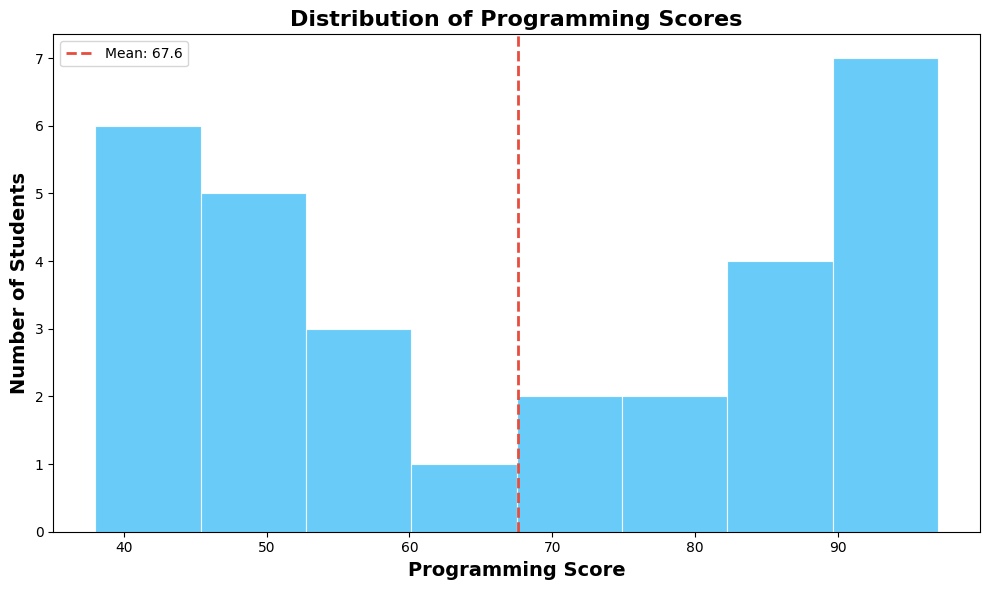

In [28]:

#====================================================================
#CELL 17 : Chart 2 -- Histogram: Distribution of programming scores
#====================================================================

#get programming scores as a list
programming_scores=df['programming_score'].tolist()
#.tolist() converts a pandas series to a regular python list
#Matplotlib's hist() works with both - tolist() is just explicit

fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    programming_scores,           # the data to visualize
    bins=8,                # divide score range into 8 equal intervals
    color='#4FC3F7',       # Bar fill color
    edgecolor='white',     # White border between bars
    linewidth=0.8,
    alpha=0.85             # slight transparence
)
#ax.hist() returns three values:
#     n     = frequency count for each bin
#   bins    = the bin edges (breakpoints on x-axis)
#  patches  = the bar objects (we can color them individually)

#Add a vertical line showing the mean score
mean_score=sum(programming_scores)/len(programming_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.1f}'    #label for the legend
)
#axvline = 'axis vertical line' - draws a vertical reference line

ax.set_title('Distribution of Programming Scores',fontsize=16,fontweight='bold')
ax.set_xlabel('Programming Score', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Students', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

#Sample dataset (replace with your own CSV)
df=pd.DataFrame({
    'Category':np.random.choice(['A','B','C','D'],100),
    'Value': np.random.randint(10,100,100),
    'Score':np.random.randint(1,100,100)
})
df.head()

,Category,Value,Score
0,A,42,68
1,A,13,40
2,A,27,90
3,D,63,68
4,A,43,86


In [30]:
import plotly.express as px
category_counts=df['Category'].value_counts().reset_index()
category_counts.columns=['Category','Count']

fig=px.bar(
    category_counts,
    x='Category',
    y='Count',
    title='Interactive Category Distribution',
    text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title="Category",yaxis_title="Count")
fig.show()


# MINI PROJECT : STUDENT PERFORMANCE DASHBOARD

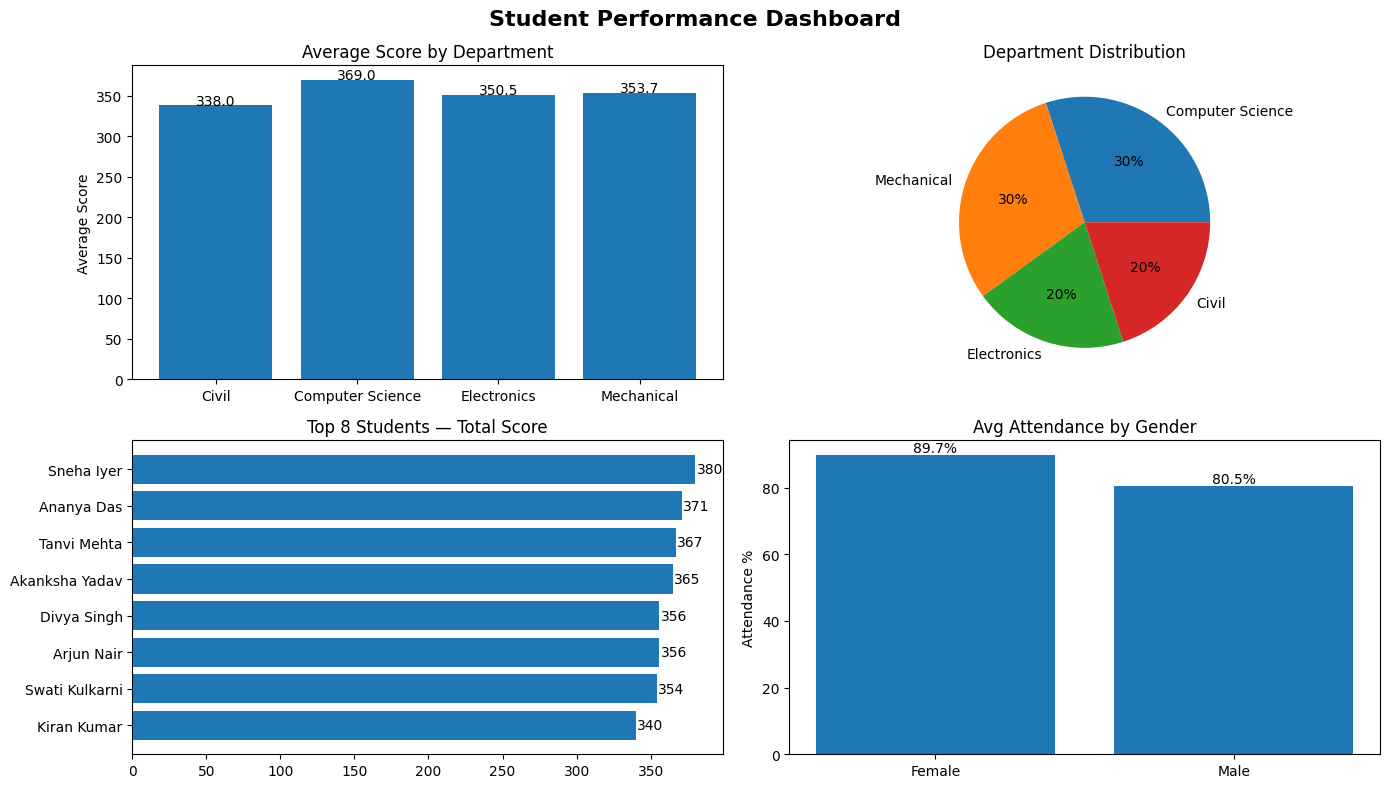

In [31]:
# ================================
# STUDENT ANALYSIS DASHBOARD
# ================================

# This dashboard visualizes:
# 1. Average Score by Department
# 2. Department Distribution
# 3. Top 8 Students by Total Score
# 4. Average Attendance by Gender

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Sample Dataset
# -------------------------------
data = {
    'Name': ['Ananya Das', 'Tanvi Mehta', 'Akanksha Yadav',
             'Arjun Nair', 'Divya Singh', 'Swati Kulkarni',
             'Amit Bose', 'Rahul Sharma', 'Sneha Iyer', 'Kiran Kumar'],

    'Department': ['Computer Science', 'Mechanical', 'Electronics',
                   'Computer Science', 'Civil', 'Mechanical',
                   'Electronics', 'Civil', 'Computer Science', 'Mechanical'],

    'Gender': ['Female', 'Female', 'Female',
               'Male', 'Female', 'Female',
               'Male', 'Male', 'Female', 'Male'],

    'Total_Score': [371, 367, 365, 356, 356, 354, 336, 320, 380, 340],

    'Attendance': [92, 89, 87, 78, 90, 86, 79, 82, 94, 83]
}

# Create DataFrame
df = pd.DataFrame(data)

# -------------------------------
# Create Dashboard Layout
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Student Performance Dashboard", fontsize=16, fontweight='bold')

# =====================================================
# 1. Average Score by Department (Bar Chart)
# =====================================================
avg_scores = df.groupby('Department')['Total_Score'].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)

axes[0, 0].set_title("Average Score by Department")
axes[0, 0].set_ylabel("Average Score")

# Add score labels
for i, value in enumerate(avg_scores.values):
    axes[0, 0].text(i, value + 1, f"{value:.1f}", ha='center')

# =====================================================
# 2. Department Distribution (Pie Chart)
# =====================================================
dept_counts = df['Department'].value_counts()

axes[0, 1].pie(
    dept_counts.values,
    labels=dept_counts.index,
    autopct='%1.0f%%'
)

axes[0, 1].set_title("Department Distribution")

# =====================================================
# 3. Top 8 Students - Total Score (Horizontal Bar Chart)
# =====================================================
top_students = df.sort_values(by='Total_Score', ascending=False).head(8)

axes[1, 0].barh(top_students['Name'], top_students['Total_Score'])

axes[1, 0].set_title("Top 8 Students — Total Score")

# Highest score at top
axes[1, 0].invert_yaxis()

# Add score labels
for i, value in enumerate(top_students['Total_Score']):
    axes[1, 0].text(value + 1, i, str(value), va='center')

# =====================================================
# 4. Average Attendance by Gender (Bar Chart)
# =====================================================
attendance_gender = df.groupby('Gender')['Attendance'].mean()

axes[1, 1].bar(attendance_gender.index, attendance_gender.values)

axes[1, 1].set_title("Avg Attendance by Gender")
axes[1, 1].set_ylabel("Attendance %")

# Add attendance labels
for i, value in enumerate(attendance_gender.values):
    axes[1, 1].text(i, value + 1, f"{value:.1f}%", ha='center')
# -------------------------------
# Adjust Layout
# -------------------------------
plt.tight_layout()
# Show Dashboard
plt.show()

# Practice Questions
Question 1:

Write a SQL query to find the average programming score for female students only.

Question 2:

What is the difference between WHERE and HAVING? Write one example of each using the students table.

Question 3:

Write a SQL query to find all departments where the average attendance is above 85%.

Question 4:

What does pd.read_sql_query() return? What two arguments does it require?

Question 5:

Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

 avg_programming_score
                  70.2
          name  math_score
  Aarav Sharma          85
    Arjun Nair          92
   Divya Singh          88
    Ananya Das          95
    Suresh Rao          83
  Ritu Agarwal          87
Swati Kulkarni          90
   Tanvi Mehta          93
     Amit Bose          86
 Gaurav Shukla          84
Akanksha Yadav          91
      department  avg_attendance
Computer Science       90.692308
      department  avg_attendance
Computer Science       90.692308
    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female     

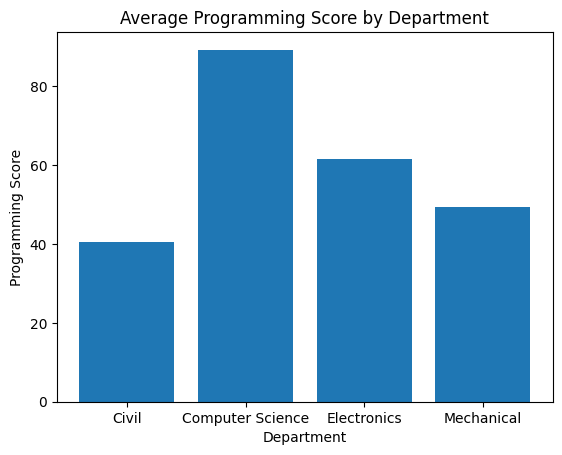

In [32]:
# Question 1
query_q1 = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female';
"""
run_query(query_q1)


# Question 2

# WHERE → filters rows before GROUP BY
query_where = """
SELECT name, math_score
FROM students
WHERE math_score > 80;
"""
run_query(query_where)

# HAVING → filters groups after GROUP BY
query_having = """
SELECT department, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""
run_query(query_having)

# Question 3
query_q3 = """
SELECT department, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""
run_query(query_q3)


# Question 4
# pd.read_sql_query() returns a Pandas DataFrame

# Required arguments:
# 1. SQL query
# 2. Database connection object

df = pd.read_sql_query(
    "SELECT * FROM students",
    conn
)

print(df)


# Question 5
avg_programming = df.groupby('department')['programming_score'].mean()

plt.bar(avg_programming.index, avg_programming.values)

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Programming Score")
plt.show()

In [33]:
run_query("SELECT * FROM students")

 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year dept_code
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023        CS
       1002    Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87          Ahmedabad            2023        CS
       1003    Rohit Verma   19   Male      Electronics         2          65             74             61                 55                     78              Delhi            2023        EC
       1004    Sneha Reddy   20 Female       Mechanical         2          70             80             75                 48                     95          Hyderabad            2023        ME
       1005     Arjun Nai

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year,dept_code
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023,CS
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023,CS
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023,EC
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023,ME
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023,CS
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023,EC
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023,CE
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023,CS
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023,ME
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023,CS


# TASK :SQLite student database
1. Find total number of students

2. Display all col names ansd data types using PRAGMA

3. Show the first 5 rows from the students table.

4. Display the student with math marks >80

5. Count the number of male and female students

6. Find the avg math score of all the students

In [34]:
# Question 1
query_q1 = "SELECT COUNT(*) AS total_students FROM students;"
run_query(query_q1)


# Question 2
cursor.execute("PRAGMA table_info(students)")
columns = cursor.fetchall()

for col in columns:
    print(col[1], "-", col[2])


# Question 3
query_q3 = "SELECT * FROM students LIMIT 5;"
run_query(query_q3)


# Question 4
query_q4 = """
SELECT name, math_score, department
FROM students
WHERE math_score > 80;
"""
run_query(query_q4)


# Question 5
query_q5 = """
SELECT gender, COUNT(*) AS total_students
FROM students
GROUP BY gender;
"""
run_query(query_q5)

# Question 6
query_q6 = """
SELECT AVG(math_score) AS avg_math_score
FROM students;
"""
run_query(query_q6)

 total_students
             30
student_id - INTEGER
name - TEXT
age - INTEGER
gender - TEXT
department - TEXT
semester - INTEGER
math_score - INTEGER
science_score - INTEGER
english_score - INTEGER
programming_score - INTEGER
attendance_percentage - INTEGER
city - TEXT
admission_year - INTEGER
dept_code - TEXT
 student_id         name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage      city  admission_year dept_code
       1001 Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92    Mumbai            2023        CS
       1002  Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87 Ahmedabad            2023        CS
       1003  Rohit Verma   19   Male      Electronics         2          65             74             61                 55           

,avg_math_score
0,76.066667
